# M1 LSTM Multimodal Training Notebook (Text + Image)

Architecture:
- **Text Stream**: Bi-LSTM encoder (question)
- **Image Stream**: CNN encoder (ResNet18 backbone)
- **Fusion**: LSTM layer combines text + image features
- **Decoder**: Text generation (answer)

Data: data_warehouse.csv with (question, answer, images_path) tuples

## 1. Imports & Config

In [1]:
import os
import json
import csv
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from PIL import Image
import logging

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

from transformers import AutoTokenizer, AutoModel

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Project root: {PROJECT_ROOT}")
print(f"Using device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

Project root: K:\GithubRepo\New folder\elementary-math-chatbot
Using device: cuda
CUDA available: True


## 2. Hyperparameter Configuration Cell

In [2]:
HYPERPARAMS = {
    'phobert_model_name': 'vinai/phobert-base',
    'text_max_len': 128,
    'phobert_frozen': True,
    'text_bilstm_hidden_dim': 512,
    'text_bilstm_layers': 1,
    'text_dropout': 0.2,

    'cnn_backbone': 'resnet18',
    'cnn_proj_dim': 512,
    'cnn_dropout': 0.2,

    'fusion_dim': 512,
    'fusion_dropout': 0.2,

    'decoder_embed_dim': 256,
    'decoder_hidden_dim': 512,
    'decoder_layers': 2,
    'decoder_dropout': 0.3,

    'num_epochs': 5,
    'batch_size': 8,
    'learning_rate': 0.0005,
    'weight_decay': 1e-5,
    'gradient_clip': 1.0,
    'log_every_n_steps': 100,

    'max_gen_len': 100,
    'temperature': 0.7,
}

print("\n" + "="*60)
print("HYPERPARAMETER CONFIGURATION")
print("="*60)
for key, val in HYPERPARAMS.items():
    print(f"{key:30s}: {val}")
print("="*60)


HYPERPARAMETER CONFIGURATION
phobert_model_name            : vinai/phobert-base
text_max_len                  : 128
phobert_frozen                : True
text_bilstm_hidden_dim        : 512
text_bilstm_layers            : 1
text_dropout                  : 0.2
cnn_backbone                  : resnet18
cnn_proj_dim                  : 512
cnn_dropout                   : 0.2
fusion_dim                    : 512
fusion_dropout                : 0.2
decoder_embed_dim             : 256
decoder_hidden_dim            : 512
decoder_layers                : 2
decoder_dropout               : 0.3
num_epochs                    : 5
batch_size                    : 8
learning_rate                 : 0.0005
weight_decay                  : 1e-05
gradient_clip                 : 1.0
log_every_n_steps             : 100
max_gen_len                   : 100
temperature                   : 0.7


## 3. Multimodal LSTM Architecture

In [3]:
class PhoBERTBiLSTMEncoder(nn.Module):
    def __init__(self, model_name, hidden_dim, num_layers=1, dropout=0.2, frozen=True):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        if frozen:
            for p in self.phobert.parameters():
                p.requires_grad = False

        phobert_dim = self.phobert.config.hidden_size
        self.bilstm = nn.LSTM(
            input_size=phobert_dim,
            hidden_size=hidden_dim // 2,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        seq = self.dropout(outputs.last_hidden_state)
        _, (h, _) = self.bilstm(seq)
        context = torch.cat([h[-2], h[-1]], dim=-1)
        return context


class ResNet18Encoder(nn.Module):
    def __init__(self, proj_dim=512, dropout=0.2):
        super().__init__()
        backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        self.proj = nn.Sequential(
            nn.Linear(512, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, image):
        feat = self.backbone(image).flatten(1)
        return self.proj(feat)


class GatedFusion(nn.Module):
    def __init__(self, text_dim, image_dim, fusion_dim, dropout=0.2):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, fusion_dim)
        self.image_proj = nn.Linear(image_dim, fusion_dim)
        self.gate = nn.Linear(fusion_dim * 2, fusion_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text_feat, image_feat):
        t = self.text_proj(text_feat)
        i = self.image_proj(image_feat)
        g = torch.sigmoid(self.gate(torch.cat([t, i], dim=-1)))
        fused = g * t + (1.0 - g) * i
        return self.dropout(fused)


class DecoderLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim + hidden_dim,
            hidden_size=hidden_dim,
            num_layers=layers,
            batch_first=True,
            dropout=dropout if layers > 1 else 0.0,
        )
        self.output = nn.Linear(hidden_dim, vocab_size)

    def forward(self, answer_ids, fused_context):
        emb = self.embedding(answer_ids)
        ctx = fused_context.unsqueeze(1).expand(-1, answer_ids.size(1), -1)
        dec_in = torch.cat([emb, ctx], dim=-1)
        dec_out, _ = self.lstm(dec_in)
        return self.output(dec_out)


class MultimodalPhoBERTResNetModel(nn.Module):
    def __init__(self, vocab_size, hyperparams, pad_idx=0):
        super().__init__()
        self.text_encoder = PhoBERTBiLSTMEncoder(
            model_name=hyperparams['phobert_model_name'],
            hidden_dim=hyperparams['text_bilstm_hidden_dim'],
            num_layers=hyperparams['text_bilstm_layers'],
            dropout=hyperparams['text_dropout'],
            frozen=hyperparams['phobert_frozen'],
        )
        self.image_encoder = ResNet18Encoder(
            proj_dim=hyperparams['cnn_proj_dim'],
            dropout=hyperparams['cnn_dropout'],
        )
        self.fusion = GatedFusion(
            text_dim=hyperparams['text_bilstm_hidden_dim'],
            image_dim=hyperparams['cnn_proj_dim'],
            fusion_dim=hyperparams['fusion_dim'],
            dropout=hyperparams['fusion_dropout'],
        )
        self.decoder = DecoderLSTM(
            vocab_size=vocab_size,
            embed_dim=hyperparams['decoder_embed_dim'],
            hidden_dim=hyperparams['decoder_hidden_dim'],
            layers=hyperparams['decoder_layers'],
            dropout=hyperparams['decoder_dropout'],
            pad_idx=pad_idx,
        )
        self.fusion_to_decoder = nn.Linear(hyperparams['fusion_dim'], hyperparams['decoder_hidden_dim'])

    def forward(self, input_ids, attention_mask, image_tensor, answer_ids):
        text_feat = self.text_encoder(input_ids, attention_mask)
        image_feat = self.image_encoder(image_tensor)
        fused = self.fusion(text_feat, image_feat)
        fused = self.fusion_to_decoder(fused)
        return self.decoder(answer_ids, fused)

print("✓ PhoBERT + ResNet18 + Gated Fusion + Decoder LSTM architecture defined")

✓ PhoBERT + ResNet18 + Gated Fusion + Decoder LSTM architecture defined


## 4. Dataset & Data Loading

In [4]:
class MultimodalMathDataset(Dataset):
    def __init__(self, data_list, vocab, tokenizer, project_root, text_max_len=128, img_size=(224, 224), transform=None):
        self.data = data_list
        self.vocab = vocab
        self.tokenizer = tokenizer
        self.project_root = project_root
        self.text_max_len = text_max_len
        self.img_size = img_size
        self.transform = transform or self._get_default_transform()
        self.pad_idx = self.vocab.get('<PAD>', 0)

    def _get_default_transform(self):
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.data)

    def create_black_image(self):
        return Image.new('RGB', self.img_size, color=(0, 0, 0))

    def load_image(self, images_path):
        if not images_path or len(images_path) == 0:
            return self.create_black_image()
        try:
            img_path = self.project_root / images_path[0]
            if img_path.exists():
                return Image.open(img_path).convert('RGB').resize(self.img_size)
        except Exception:
            pass
        return self.create_black_image()

    def encode_question(self, question):
        text = question.strip() if question and question.strip() else '<PAD>'
        encoded = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.text_max_len,
            return_tensors='pt'
        )
        input_ids = encoded['input_ids'].squeeze(0)
        attention_mask = encoded['attention_mask'].squeeze(0)
        return input_ids, attention_mask

    def encode_answer_chars(self, answer, max_len=127):
        if not answer or not answer.strip():
            return torch.tensor([self.pad_idx] * max_len, dtype=torch.long)
        tokens = [self.vocab.get(ch, self.vocab.get('<UNK>', 1)) for ch in answer]
        if len(tokens) > max_len:
            tokens = tokens[:max_len]
        else:
            tokens += [self.pad_idx] * (max_len - len(tokens))
        return torch.tensor(tokens, dtype=torch.long)

    def __getitem__(self, idx):
        question, answer, images_path = self.data[idx]
        input_ids, attention_mask = self.encode_question(question)
        y = self.encode_answer_chars(answer)
        image = self.load_image(images_path)
        image_tensor = self.transform(image)
        return input_ids, attention_mask, image_tensor, y


def parse_list_cell(raw_value):
    if not raw_value or raw_value.strip() in ['', '[]', '[""]']:
        return []
    try:
        return json.loads(raw_value)
    except Exception:
        return []


def collect_vocab_text(row):
    parts = []
    for field in ['question', 'answer', 'right_choice', 'instruction']:
        value = row.get(field, '')
        if value and str(value).strip():
            parts.append(str(value).strip())
    choices = parse_list_cell(row.get('choices', ''))
    parts.extend([str(choice).strip() for choice in choices if str(choice).strip()])
    return ' '.join(parts)


def load_data_from_csv(csv_path):
    data_list = []
    with open(csv_path, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            question = row.get('question', '').strip()
            answer = row.get('answer', '').strip()
            images_path = parse_list_cell(row.get('images_path', ''))
            data_list.append((question, answer, images_path))
    return data_list


def build_vocab_from_rows(rows):
    vocab = {'<PAD>': 0, '<UNK>': 1}
    idx = 2
    for row in rows:
        text = collect_vocab_text(row)
        if not text:
            continue
        for char in text:
            if char not in vocab:
                vocab[char] = idx
                idx += 1
    return vocab

print('✓ Dataset classes defined')

✓ Dataset classes defined


## 5. Load Data & Build Vocabulary

In [5]:
csv_path = PROJECT_ROOT / "data_warehouse.csv"
print(f"Loading data from {csv_path}...")

if not csv_path.exists():
    print(f"ERROR: {csv_path} not found!")
    raise FileNotFoundError(f"Data file not found: {csv_path}")
else:
    data_list = load_data_from_csv(csv_path)
    raw_rows = []
    with open(csv_path, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            raw_rows.append(row)
    print(f"✓ Loaded {len(data_list)} records from CSV")
    
    data_with_images = sum(1 for item in data_list if len(item) > 2 and item[2])
    print(f"  - Records with images: {data_with_images}")
    print(f"  - Records without images: {len(data_list) - data_with_images}")
    
    valid_records = sum(1 for item in data_list if item[0].strip() and item[1].strip())
    print(f"  - Valid records (both text+answer): {valid_records}")
    
    train_data, test_data = train_test_split(data_list, test_size=0.2, random_state=42)
    train_rows, test_rows = train_test_split(raw_rows, test_size=0.2, random_state=42)
    print(f"\n✓ Train/test split:")
    print(f"  - Train: {len(train_data)} samples")
    print(f"  - Test: {len(test_data)} samples")
    
    print(f"\nBuilding vocabulary from all textual CSV fields...")
    vocab = build_vocab_from_rows(train_rows)
    vocab_size = len(vocab)
    print(f"✓ Vocabulary size: {vocab_size}")
    
    vocab_path = PROJECT_ROOT / "models/m1_lstm/vocab.json"
    os.makedirs(vocab_path.parent, exist_ok=True)
    with open(vocab_path, 'w', encoding='utf-8') as f:
        json.dump(vocab, f, ensure_ascii=False)
    print(f"✓ Vocabulary saved to {vocab_path}")

Loading data from K:\GithubRepo\New folder\elementary-math-chatbot\data_warehouse.csv...
✓ Loaded 96572 records from CSV
  - Records with images: 15555
  - Records without images: 81017
  - Valid records (both text+answer): 96502

✓ Train/test split:
  - Train: 77257 samples
  - Test: 19315 samples

Building vocabulary from all textual CSV fields...
✓ Vocabulary size: 252
✓ Vocabulary saved to K:\GithubRepo\New folder\elementary-math-chatbot\models\m1_lstm\vocab.json


## 6. Create DataLoaders

In [6]:
tokenizer = AutoTokenizer.from_pretrained(HYPERPARAMS['phobert_model_name'])

train_dataset = MultimodalMathDataset(
    train_data, vocab, tokenizer, PROJECT_ROOT,
    text_max_len=HYPERPARAMS['text_max_len'], img_size=(224, 224)
)
test_dataset = MultimodalMathDataset(
    test_data, vocab, tokenizer, PROJECT_ROOT,
    text_max_len=HYPERPARAMS['text_max_len'], img_size=(224, 224)
)

def collate_fn(batch):
    input_ids, attention_masks, images, answers = zip(*batch)
    return (
        torch.stack(input_ids),
        torch.stack(attention_masks),
        torch.stack(images),
        torch.stack(answers)
    )

batch_size = HYPERPARAMS['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"✓ DataLoaders created:")
print(f"  - Train batches: {len(train_loader)}")
print(f"  - Test batches: {len(test_loader)}")
print(f"  - Batch size: {batch_size}")

✓ DataLoaders created:
  - Train batches: 9658
  - Test batches: 2415
  - Batch size: 8


## 7. Initialize Model & Training Setup

In [7]:
pad_idx = vocab.get('<PAD>', 0)
model = MultimodalPhoBERTResNetModel(vocab_size, HYPERPARAMS, pad_idx=pad_idx)
model.to(device)

print(f"\n✓ Model initialized:")
print(f"  - PhoBERT: {HYPERPARAMS['phobert_model_name']} (frozen={HYPERPARAMS['phobert_frozen']})")
print(f"  - Backbone: {HYPERPARAMS['cnn_backbone']}")
print(f"  - Fusion dim: {HYPERPARAMS['fusion_dim']}")
print(f"  - Decoder hidden dim: {HYPERPARAMS['decoder_hidden_dim']}")
print(f"  - Vocab size: {vocab_size}")
print(f"  - Device: {device}")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  - Total parameters: {total_params:,}")
print(f"  - Trainable parameters: {trainable_params:,}")

criterion = nn.CrossEntropyLoss(ignore_index=pad_idx, label_smoothing=0.05)
optimizer = torch.optim.AdamW(
    (p for p in model.parameters() if p.requires_grad),
    lr=HYPERPARAMS['learning_rate'],
    weight_decay=HYPERPARAMS['weight_decay']
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=HYPERPARAMS['num_epochs'])

print(f"\n✓ Optimizer & Loss initialized")
print(f"  - Learning rate: {HYPERPARAMS['learning_rate']}")
print(f"  - Gradient clip: {HYPERPARAMS['gradient_clip']}")
print(f"  - Loss: CrossEntropy(ignore PAD, label_smoothing=0.05)")


✓ Model initialized:
  - PhoBERT: vinai/phobert-base (frozen=True)
  - Backbone: resnet18
  - Fusion dim: 512
  - Decoder hidden dim: 512
  - Vocab size: 252
  - Device: cuda
  - Total parameters: 154,772,028
  - Trainable parameters: 19,773,756

✓ Optimizer & Loss initialized
  - Learning rate: 0.0005
  - Gradient clip: 1.0
  - Loss: CrossEntropy(ignore PAD, label_smoothing=0.05)


## 8. Training Loop

In [8]:
log_dir = PROJECT_ROOT / "models/m1_lstm/logs"
os.makedirs(log_dir, exist_ok=True)
checkpoints_dir = PROJECT_ROOT / "models/m1_lstm/checkpoints"
os.makedirs(checkpoints_dir, exist_ok=True)
csv_log_path = log_dir / "training_log.csv"
best_model_path = checkpoints_dir / "best_model.pt"

with open(csv_log_path, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'step', 'loss', 'learning_rate'])

print(f"\n{'='*60}")
print(f"STARTING TRAINING - {HYPERPARAMS['num_epochs']} epochs")
print(f"{'='*60}")

if len(train_loader) == 0:
    raise ValueError('Train loader is empty; check input data and batch size.')

model.train()
global_step = 0
train_losses = []
best_epoch_loss = float('inf')
best_epoch = -1

epoch_bar = tqdm(range(HYPERPARAMS['num_epochs']), desc='Epochs', unit='epoch', position=0, leave=True, dynamic_ncols=True)
for epoch in epoch_bar:
    model.train()
    epoch_loss = 0.0
    batch_count = 0

    batch_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{HYPERPARAMS["num_epochs"]}', unit='batch', position=1, leave=False, dynamic_ncols=True)
    for input_ids, attention_mask, img, y in batch_bar:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        img = img.to(device)
        y = y.to(device)

        decoder_in = y[:, :-1]
        decoder_target = y[:, 1:]

        optimizer.zero_grad(set_to_none=True)
        logits = model(input_ids, attention_mask, img, decoder_in)

        loss = criterion(logits.reshape(-1, vocab_size), decoder_target.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), HYPERPARAMS['gradient_clip'])
        optimizer.step()

        global_step += 1
        batch_count += 1
        epoch_loss += loss.item()

        lr = optimizer.param_groups[0]['lr']
        batch_bar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{lr:.2e}', 'step': global_step}, refresh=True)

        if global_step % HYPERPARAMS['log_every_n_steps'] == 0:
            with open(csv_log_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([epoch + 1, global_step, f"{loss.item():.4f}", f"{lr:.8f}"])

    avg_epoch_loss = epoch_loss / max(1, batch_count)
    train_losses.append(avg_epoch_loss)
    scheduler.step()

    if avg_epoch_loss < best_epoch_loss:
        best_epoch_loss = avg_epoch_loss
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'vocab': vocab,
            'vocab_size': vocab_size,
            'hyperparams': HYPERPARAMS,
            'avg_epoch_loss': avg_epoch_loss,
        }, best_model_path)
        tqdm.write(f"✓ Best model updated at epoch {epoch + 1}: loss={avg_epoch_loss:.4f}")

    epoch_bar.set_postfix({'avg_loss': f'{avg_epoch_loss:.4f}', 'best': f'{best_epoch_loss:.4f}'}, refresh=True)
    print(f"Epoch {epoch + 1} | Avg Loss: {avg_epoch_loss:.4f}")

print(f"\n{'='*60}")
print("✓ TRAINING COMPLETE")
print(f"✓ Best epoch: {best_epoch + 1 if best_epoch >= 0 else 'N/A'} | Best loss: {best_epoch_loss:.4f}")
print(f"{'='*60}")


STARTING TRAINING - 5 epochs


Epochs:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch 1/5:   0%|          | 0/9658 [00:00<?, ?batch/s]

✓ Best model updated at epoch 1: loss=1.4782
Epoch 1 | Avg Loss: 1.4782


Epoch 2/5:   0%|          | 0/9658 [00:00<?, ?batch/s]

...

✓ Best model updated at epoch 3: loss=1.1224
Epoch 3 | Avg Loss: 1.1224


Epoch 4/5:   0%|          | 0/9658 [00:00<?, ?batch/s]

✓ Best model updated at epoch 4: loss=1.0783
Epoch 4 | Avg Loss: 1.0783


Epoch 5/5:   0%|          | 0/9658 [00:00<?, ?batch/s]

✓ Best model updated at epoch 5: loss=1.0515
Epoch 5 | Avg Loss: 1.0515

✓ TRAINING COMPLETE
✓ Best epoch: 5 | Best loss: 1.0515


## 9. Save Model

In [9]:
final_output_dir = PROJECT_ROOT / "models/m1_lstm/final"
os.makedirs(final_output_dir, exist_ok=True)

model_path = final_output_dir / "model.pt"
torch.save(model.state_dict(), model_path)
print(f"✓ Model saved to {model_path}")

hyperparams_path = final_output_dir / "hyperparams.json"
with open(hyperparams_path, 'w') as f:
    json.dump(HYPERPARAMS, f, indent=2)
print(f"✓ Hyperparameters saved to {hyperparams_path}")

vocab_save_path = final_output_dir / "vocab.json"
with open(vocab_save_path, 'w', encoding='utf-8') as f:
    json.dump(vocab, f, ensure_ascii=False)
print(f"✓ Vocabulary saved to {vocab_save_path}")

✓ Model saved to K:\GithubRepo\New folder\elementary-math-chatbot\models\m1_lstm\final\model.pt
✓ Hyperparameters saved to K:\GithubRepo\New folder\elementary-math-chatbot\models\m1_lstm\final\hyperparams.json
✓ Vocabulary saved to K:\GithubRepo\New folder\elementary-math-chatbot\models\m1_lstm\final\vocab.json


## 10. Evaluation on Test Set

In [10]:
print(f"\n{'='*60}")
print("EVALUATION ON TEST SET")
print(f"{'='*60}")

model.eval()
test_loss = 0.0
total_batches = 0

with torch.no_grad():
    for input_ids, attention_mask, img, y in test_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        img = img.to(device)
        y = y.to(device)

        decoder_in = y[:, :-1]
        decoder_target = y[:, 1:]

        logits = model(input_ids, attention_mask, img, decoder_in)
        loss = criterion(logits.reshape(-1, vocab_size), decoder_target.reshape(-1))

        test_loss += loss.item()
        total_batches += 1

avg_test_loss = test_loss / max(1, total_batches)
print(f"\nAverage Test Loss: {avg_test_loss:.4f}")
print(f"Average Train Loss (last epoch): {train_losses[-1]:.4f}")
print(f"Gap (test-train): {(avg_test_loss - train_losses[-1]):.4f}")


EVALUATION ON TEST SET

Average Test Loss: 1.0493
Average Train Loss (last epoch): 1.0515
Gap (test-train): -0.0022


## 11. Visualization

KeyError: 'text_embed_dim'

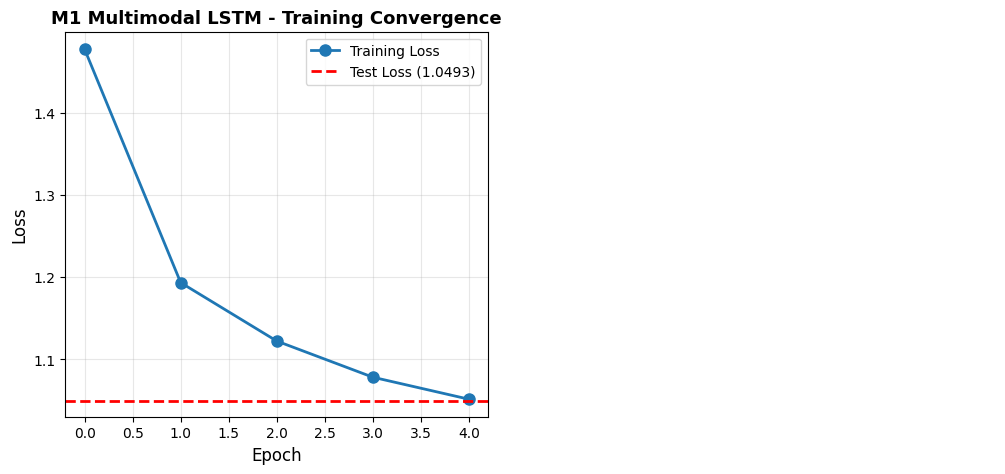

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o', linewidth=2, markersize=8, label='Training Loss')
plt.axhline(y=avg_test_loss, color='r', linestyle='--', linewidth=2, label=f'Test Loss ({avg_test_loss:.4f})')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('M1 Multimodal LSTM - Training Convergence', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.axis('off')
info_text = f"""
MULTIMODAL LSTM ARCHITECTURE

Text Stream:
  • Embedding: {HYPERPARAMS['text_embed_dim']} dims
  • Bi-LSTM: {HYPERPARAMS['text_hidden_dim']} hidden
  • Layers: {HYPERPARAMS['text_num_layers']}

Image Stream:
  • Backbone: {HYPERPARAMS['cnn_backbone'].upper()}
  • Hidden: {HYPERPARAMS['cnn_hidden_dim']} dims

Fusion:
  • Hidden: {HYPERPARAMS['fusion_hidden_dim']} dims
  • Layers: {HYPERPARAMS['fusion_num_layers']}

Training:
  • Epochs: {HYPERPARAMS['num_epochs']}
  • Batch size: {HYPERPARAMS['batch_size']}
  • LR: {HYPERPARAMS['learning_rate']}
  • Final train loss: {train_losses[-1]:.4f}
  • Test loss: {avg_test_loss:.4f}
"""
plt.text(0.05, 0.95, info_text, transform=plt.gca().transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plot_path = PROJECT_ROOT / "models/m1_lstm/training_summary.png"
os.makedirs(plot_path.parent, exist_ok=True)
plt.savefig(plot_path, dpi=100, bbox_inches='tight')
plt.show()

print(f"✓ Training summary plot saved to {plot_path}")

## 12. Text Generation Function

In [12]:
def generate_text_multimodal(model, vocab, tokenizer, question_text, image_tensor, device, max_len=100, temperature=0.7):
    model.eval()
    vocab_reverse = {v: k for k, v in vocab.items()}
    pad_idx = vocab.get('<PAD>', 0)

    if not question_text or not question_text.strip():
        question_text = '<PAD>'

    encoded = tokenizer(
        question_text,
        truncation=True,
        padding='max_length',
        max_length=HYPERPARAMS['text_max_len'],
        return_tensors='pt'
    )
    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)
    image_tensor = image_tensor.to(device)

    generated = [pad_idx]

    with torch.no_grad():
        for _ in range(max_len):
            decoder_in = torch.tensor([generated], dtype=torch.long, device=device)
            logits = model(input_ids, attention_mask, image_tensor, decoder_in)
            next_logits = logits[:, -1, :] / max(temperature, 1e-6)
            probs = torch.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
            generated.append(next_token)
            if next_token == pad_idx:
                break

    text = ''.join(vocab_reverse.get(t, '?') for t in generated[1:] if t != pad_idx)
    return text

print('✓ Text generation function defined')

✓ Text generation function defined


## 13. Interactive Prediction - Text + Image Input 🎯

In [14]:
print("\n" + "="*70)
print(" INTERACTIVE MULTIMODAL PREDICTION - TEXT + IMAGE INPUT")
print("="*70)

user_question = input("Nhập bài toán (có thể để trống nếu chỉ dùng ảnh): ").strip()
image_path_input = input("Nhập đường dẫn ảnh (hoặc Enter để dùng black image): ").strip()

if image_path_input:
    try:
        img_path = PROJECT_ROOT / image_path_input
        if img_path.exists():
            image = Image.open(img_path).convert('RGB').resize((224, 224))
            print(f"✓ Ảnh đã tải: {image_path_input}")
        else:
            image = Image.new('RGB', (224, 224), color=(0, 0, 0))
            print('⚠ Không tìm thấy ảnh, dùng black image')
    except Exception as e:
        image = Image.new('RGB', (224, 224), color=(0, 0, 0))
        print(f'⚠ Lỗi tải ảnh ({e}), dùng black image')
else:
    image = Image.new('RGB', (224, 224), color=(0, 0, 0))
    print('→ Dùng black image')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
image_tensor = transform(image).unsqueeze(0)

generated_answer = generate_text_multimodal(
    model=model,
    vocab=vocab,
    tokenizer=tokenizer,
    question_text=user_question if user_question else '<PAD>',
    image_tensor=image_tensor,
    device=device,
    max_len=HYPERPARAMS['max_gen_len'],
    temperature=HYPERPARAMS['temperature']
)

print("\n" + "="*70)
print(f"Bài toán: {user_question if user_question else '<PAD>'}")
print("\nGiải pháp được tạo ra:")
print(generated_answer[:500] + ('...' if len(generated_answer) > 500 else ''))
print("="*70)


 INTERACTIVE MULTIMODAL PREDICTION - TEXT + IMAGE INPUT
→ Dùng black image

Bài toán: Có một con cừu đi qua sông, con cừu đó đi với 3 con cừu nữa. Hỏi có mấy con cừu?

Giải pháp được tạo ra:
viết các số chim là số con ngựa có trong biểu thức nhỏ hơn. Chúng ta cần đưa tính tổng các con vật c


## 14. Batch Testing

In [ ]:
print("\n" + "="*70)
print(" BATCH TESTING ON TEST SET")
print("="*70)

model.eval()
num_test_samples = min(5, len(test_data))
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for idx in range(num_test_samples):
    question, answer, images_path = test_data[idx]

    if images_path and len(images_path) > 0:
        try:
            img_path = PROJECT_ROOT / images_path[0]
            if img_path.exists():
                image = Image.open(img_path).convert('RGB').resize((224, 224))
            else:
                image = Image.new('RGB', (224, 224), color=(0, 0, 0))
        except Exception:
            image = Image.new('RGB', (224, 224), color=(0, 0, 0))
    else:
        image = Image.new('RGB', (224, 224), color=(0, 0, 0))

    image_tensor = transform(image).unsqueeze(0)
    generated = generate_text_multimodal(
        model=model,
        vocab=vocab,
        tokenizer=tokenizer,
        question_text=question if question else '<PAD>',
        image_tensor=image_tensor,
        device=device,
        max_len=HYPERPARAMS['max_gen_len'],
        temperature=0.5
    )

    print(f"\n[Sample {idx+1}]")
    print(f"Q: {question[:120]}" if question else "Q: <PAD>")
    print(f"Ground truth: {answer[:120]}" if answer else "Ground truth: <PAD>")
    print(f"Generated: {generated[:120]}")
    print("-" * 70)

print("✓ Batch testing completed")

## 15. Summary & Next Steps

In [ ]:
print("\n" + "="*70)
print(" TRAINING SUMMARY")
print("="*70)

summary = f"""
✓ MULTIMODAL TRAINING COMPLETE

Architecture:
  - Text Encoder: Frozen PhoBERT + BiLSTM
  - Image Encoder: ResNet18 pretrained (ImageNet)
  - Fusion: Gated fusion
  - Decoder: LSTM + Linear vocab head

Loss/Optimization:
  - CrossEntropyLoss(ignore_index=<PAD>, label_smoothing=0.05)
  - Teacher forcing with shifted targets (y[:, :-1] -> y[:, 1:])
  - Optimizer: AdamW
  - Scheduler: CosineAnnealingLR

Results:
  - Train Loss (final): {train_losses[-1]:.4f}
  - Test Loss: {avg_test_loss:.4f}
  - Total Params: {total_params:,}
  - Trainable Params: {trainable_params:,}

Saved Files:
  - Best checkpoint: {best_model_path}
  - Final model: {model_path}
  - Hyperparameters: {hyperparams_path}
  - Vocabulary: {vocab_save_path}
  - Training Log: {csv_log_path}
  - Plot: {plot_path}

Input handling:
  - Missing text: use '<PAD>'
  - Missing image: black image (224x224 RGB)
"""

print(summary)
print("="*70)

# M1 LSTM Training Notebook

Notebook nay tuong ung voi logic trong train.py cua m1_lstm.

In [ ]:
import os
import json
import csv
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import sys

# Ensure project root is importable
PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config

In [ ]:
class CustomMathDataset(Dataset):
    def __init__(self, data_path, vocab):
        self.data = []
        self.vocab = vocab
        if not os.path.exists(data_path):
            raise FileNotFoundError(f"Data not found: {data_path}")
        with open(data_path, 'r', encoding='utf-8') as f:
            for line in f:
                item = json.loads(line)
                text = f"Câu hỏi: {item['question']} Giải: {item['answer']}"
                self.data.append(text)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]
        tokens = [self.vocab.get(char, self.vocab.get("<UNK>", 0)) for char in text]
        max_len = 128
        if len(tokens) > max_len:
            tokens = tokens[:max_len]
        else:
            tokens += [self.vocab.get("<PAD>", 0)] * (max_len - len(tokens))

        x = torch.tensor(tokens[:-1], dtype=torch.long)
        y = torch.tensor(tokens[1:], dtype=torch.long)
        return x, y

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        prediction = self.fc(output)
        return prediction

def build_vocab(data_path):
    vocab = {"<PAD>": 0, "<UNK>": 1}
    idx = 2
    if not os.path.exists(data_path):
        return vocab
    with open(data_path, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            text = f"Câu hỏi: {item['question']} Giải: {item['answer']}"
            for char in text:
                if char not in vocab:
                    vocab[char] = idx
                    idx += 1
    return vocab

In [ ]:
def train():
    data_path = os.path.join(config.DATA_PROCESSED_DIR, "train.jsonl")

    print("Building vocabulary for M1 LSTM...")
    vocab = build_vocab(data_path)
    vocab_path = os.path.join(config.MODELS_DIR, "m1_lstm/vocab.json")
    os.makedirs(os.path.dirname(vocab_path), exist_ok=True)
    with open(vocab_path, 'w', encoding='utf-8') as f:
        json.dump(vocab, f, ensure_ascii=False)

    dataset = CustomMathDataset(data_path, vocab)
    dataloader = DataLoader(dataset, batch_size=config.TRAIN_BATCH_SIZE, shuffle=True)

    model = LSTMModel(len(vocab), embed_dim=256, hidden_dim=512)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=vocab.get("<PAD>", 0))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    num_epochs = 5

    csv_log_path = os.path.join(config.MODELS_DIR, "m1_lstm/logs/training_log.csv")
    os.makedirs(os.path.dirname(csv_log_path), exist_ok=True)
    with open(csv_log_path, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['step', 'epoch', 'loss', 'learning_rate'])

    print("Starting training M1 LSTM...")
    model.train()
    global_step = 0
    for epoch in range(num_epochs):
        for batch_idx, (x, y) in enumerate(dataloader):
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            output = model(x)

            output = output.view(-1, len(vocab))
            y = y.view(-1)

            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            global_step += 1
            if global_step % 10 == 0:
                print(f"Epoch {epoch}, Step {global_step}, Loss: {loss.item():.4f}")
                with open(csv_log_path, mode='a', newline='') as f:
                    writer = csv.writer(f)
                    writer.writerow([global_step, epoch, round(loss.item(), 4), optimizer.param_groups[0]['lr']])

    final_output_dir = os.path.join(config.MODELS_DIR, "m1_lstm/final")
    os.makedirs(final_output_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(final_output_dir, "model.pt"))
    print(f"Training complete. Model saved to {final_output_dir}")

In [ ]:
train()

## 16. Interactive Generative Demo with Text + Image Upload

Nhập bài toán và upload ảnh trực tiếp trong notebook để sinh lời giải.

In [ ]:
import io
import ipywidgets as widgets
from IPython.display import display, clear_output


def _prepare_uploaded_image(upload_widget, target_size=(224, 224)):
    if not upload_widget.value:
        return Image.new('RGB', target_size, color=(0, 0, 0))

    uploaded_item = next(iter(upload_widget.value.values()))
    image_bytes = uploaded_item['content']
    image = Image.open(io.BytesIO(image_bytes)).convert('RGB')
    return image.resize(target_size)


def _predict_from_widgets(question_text, upload_widget):
    if not question_text or not question_text.strip():
        print('Vui lòng nhập nội dung bài toán.')
        return

    image = _prepare_uploaded_image(upload_widget)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0)

    question_tokens = [vocab.get(char, vocab.get('<UNK>', 1)) for char in question_text.strip()]
    max_q_len = 127
    if len(question_tokens) > max_q_len:
        question_tokens = question_tokens[:max_q_len]
    else:
        question_tokens += [vocab.get('<PAD>', 0)] * (max_q_len - len(question_tokens))

    question_tensor = torch.tensor([question_tokens], dtype=torch.long)
    answer = generate_text_multimodal(
        model,
        vocab,
        question_tensor,
        image_tensor,
        device,
        max_len=HYPERPARAMS['max_gen_len'],
        temperature=HYPERPARAMS['temperature']
    )

    print('Câu hỏi:')
    print(question_text)
    print('\nĐáp án sinh ra:')
    print(answer)
    print(f'\nẢnh đầu vào: {image.size}')


question_box = widgets.Textarea(
    value='',
    placeholder='Nhập bài toán ở đây...',
    description='Text:',
    layout=widgets.Layout(width='100%', height='120px')
)
image_upload = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='Upload ảnh'
)
run_button = widgets.Button(description='Generate', button_style='primary')
output_box = widgets.Output()


def _on_run_clicked(_):
    with output_box:
        clear_output()
        _predict_from_widgets(question_box.value, image_upload)


run_button.on_click(_on_run_clicked)
display(question_box, image_upload, run_button, output_box)